<a href="https://colab.research.google.com/github/dheenseenivasan/Churn/blob/main/Student_placement_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv("/content/student_dataset_10000_rows (1).csv")
dataset.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [6]:
dataset.isnull().sum()

,0
study_hours,0
attendance,0
sleep_hours,0
internet_usage,0
assignments_completed,0
previous_score,0
exam_score,0
placement_status,0


In [7]:
print(dataset['placement_status'].value_counts())

placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64


/tmp/ipykernel_1992/1227073539.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='placement_status', data=dataset, palette='coolwarm')


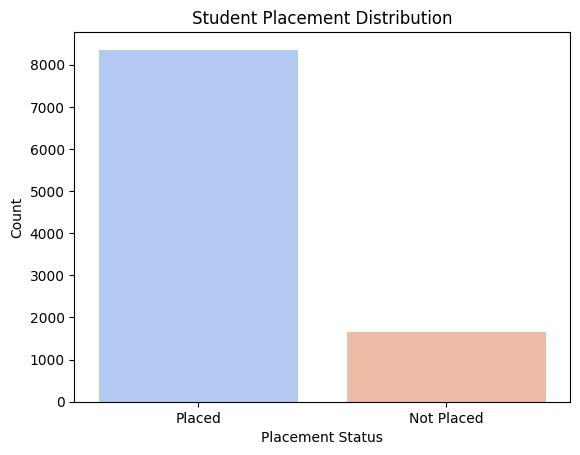

In [8]:
sns.countplot(x='placement_status', data=dataset, palette='coolwarm')
plt.title('Student Placement Distribution')
plt.xlabel('Placement Status')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1992/4012039295.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='placement_status', y='exam_score', data=dataset, palette='coolwarm')


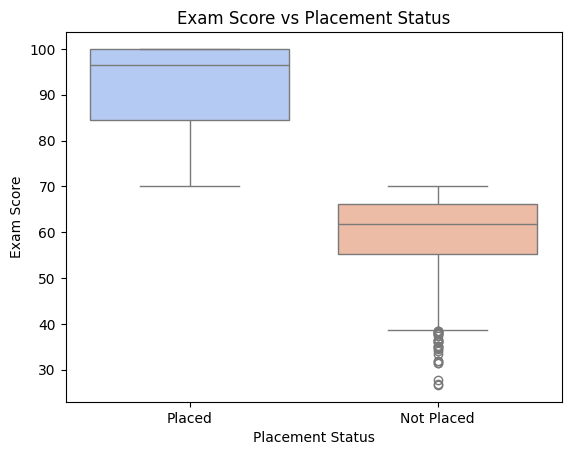

In [9]:
sns.boxplot(x='placement_status', y='exam_score', data=dataset, palette='coolwarm')
plt.title('Exam Score vs Placement Status')
plt.xlabel('Placement Status')
plt.ylabel('Exam Score')
plt.show()

In [10]:
dataset['placement_status'] = dataset['placement_status'].map({
    'Placed': 1,
    'Not Placed': 0
})

dataset.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1


In [11]:
X = dataset[['study_hours','attendance','sleep_hours','internet_usage',
             'assignments_completed','previous_score','exam_score']]

y = dataset['placement_status']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [15]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("Predicted Values:")
print(y_pred)

Actual Values:
[1 1 1 ... 1 1 0]
Predicted Values:
[1 1 1 ... 1 1 0]


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.9975


In [17]:
Vishnu = [[7, 85, 8, 3, 9, 75, 88]]

Vishnu = scaler.transform(Vishnu)
result = model.predict(Vishnu)

if result[0] == 1:
    print("Placed")
else:
    print("Not Placed")

Placed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
